# 03 — Acquisition Priority Scoring
**Merchant Network Analytics — Capstone Project BNI ODP**

---

## Tujuan
Menghitung skor prioritas akuisisi untuk setiap merchant berdasarkan
posisi mereka di Customer Affinity Graph.

**Pendekatan: Composite Scoring (bukan ML Classifier)**

Priority scoring menggunakan composite score dari graph metrics — bukan ML classifier —
karena tidak ada ground truth historis tentang "merchant mana yang seharusnya diakuisisi".

Ini adalah keputusan desain yang disengaja:
- ML classifier membutuhkan ground truth yang valid (label observasi nyata)
- Untuk acquisition priority, ground truth baru tersedia setelah akuisisi terjadi
- Composite score memberikan ranking yang transparan dan dapat dikalibrasi
  bersama business holder

**Komponen skor:**
- PageRank (30%): tingkat pengaruh merchant di jaringan
- Connected BNI Ratio (25%): proporsi mitra yang sudah nasabah BNI
- Degree (25%): jumlah koneksi affinitas
- Weighted Degree (20%): kekuatan total affinitas (sum of Jaccard)

**Input:** feature_table.csv
**Output:** merchants_with_predictions.csv (berisi priority_score dan priority_rank)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
PROJECT_ROOT = '.' if os.path.isdir('./data') else '..'

feature_table = pd.read_csv(f'{PROJECT_ROOT}/data/processed/feature_table.csv')
print(f"Feature table: {feature_table.shape}")
print(f"Kolom: {list(feature_table.columns)}")

Feature table: (708, 35)
Kolom: ['merchant_id', 'nama', 'kategori', 'sub_kategori', 'tipe', 'kota', 'kecamatan', 'is_bni_acquiring', 'produk_bni', 'tgl_registrasi', 'status', 'skala_usaha', 'avg_omzet_bulanan', 'degree', 'weighted_degree', 'pagerank', 'betweenness', 'community_id', 'community_size', 'connected_bni_ratio', 'avg_neighbor_jaccard', 'n_customers', 'lama_beroperasi_tahun', 'jumlah_karyawan', 'rating_google', 'jumlah_outlet', 'has_website', 'has_social_media', 'has_rating', 'is_hub', 'customer_density', 'log_pagerank', 'log_omzet', 'log_weighted_degree', 'log_n_customers']


## 1. Hitung Composite Priority Score

Composite score menggabungkan 4 metrik graph yang masing-masing
menjawab pertanyaan bisnis berbeda:

| Metrik | Bobot | Pertanyaan Bisnis |
|---|---|---|
| PageRank | 30% | Seberapa berpengaruh merchant di jaringan pelanggan? |
| Connected BNI Ratio | 25% | Berapa % mitra bisnis yang sudah BNI? |
| Degree | 25% | Berapa banyak merchant lain yang berbagi pelanggan? |
| Weighted Degree | 20% | Seberapa kuat total affinitas pelanggan? |

Semua metrik dinormalisasi ke [0, 1] sebelum digabungkan
agar tidak ada satu metrik yang mendominasi karena perbedaan skala.

In [2]:
# Merchant yang masuk graph (punya koneksi affinitas)
ft = feature_table.copy()

# Merchant yang tidak masuk graph mendapat skor 0
ft['in_graph'] = ft['degree'] > 0

print(f"Merchant dalam graph  : {ft['in_graph'].sum()}")
print(f"Merchant luar graph   : {(~ft['in_graph']).sum()}")
print(f"  → Merchant luar graph tidak cukup data untuk scoring berbasis jaringan")

# Normalisasi 4 komponen ke [0, 1]
SCORE_COMPONENTS = ['pagerank', 'connected_bni_ratio', 'degree', 'weighted_degree']
WEIGHTS = {'pagerank': 0.30, 'connected_bni_ratio': 0.25,
           'degree': 0.25, 'weighted_degree': 0.20}

scaler = MinMaxScaler()

# Fit dan transform hanya pada merchant yang ada di graph
in_graph_mask = ft['in_graph']
normalized_values = pd.DataFrame(
    scaler.fit_transform(ft.loc[in_graph_mask, SCORE_COMPONENTS]),
    columns=SCORE_COMPONENTS,
    index=ft[in_graph_mask].index
)

# Hitung weighted sum
ft.loc[in_graph_mask, 'priority_score'] = sum(
    normalized_values[col] * WEIGHTS[col] for col in SCORE_COMPONENTS
)
ft['priority_score'] = ft['priority_score'].fillna(0)

print(f"\nDistribusi priority score:")
print(ft[ft['in_graph']]['priority_score'].describe().round(4))

Merchant dalam graph  : 627
Merchant luar graph   : 81
  → Merchant luar graph tidak cukup data untuk scoring berbasis jaringan

Distribusi priority score:
count    627.0000
mean       0.3372
std        0.1686
min        0.0014
25%        0.2469
50%        0.3243
75%        0.4392
max        0.9404
Name: priority_score, dtype: float64


In [3]:
# Buat ranking (1 = paling prioritas)
ft['priority_rank'] = ft['priority_score'].rank(ascending=False, method='min').astype(int)

# Kategorisasi untuk display di dashboard
# Top 15% = Tinggi, 15-40% = Sedang, sisanya = Rendah
q85 = ft[ft['in_graph']]['priority_score'].quantile(0.85)
q60 = ft[ft['in_graph']]['priority_score'].quantile(0.60)

def categorize_priority(row):
    if not row['in_graph']:
        return 'Tidak Teranalisis'
    if row['priority_score'] >= q85:
        return 'Tinggi'
    elif row['priority_score'] >= q60:
        return 'Sedang'
    else:
        return 'Rendah'

ft['priority_category'] = ft.apply(categorize_priority, axis=1)

# Untuk kompatibilitas dashboard: predicted_priority = 1 jika Tinggi, 0 jika lainnya
ft['predicted_priority'] = (ft['priority_category'] == 'Tinggi').astype(int)
# priority_probability = priority_score (dipakai sebagai proxy confidence)
ft['priority_probability'] = ft['priority_score']

print("=== Distribusi Priority Category ===")
print(ft['priority_category'].value_counts())
print(f"\nTop 15% threshold: {q85:.4f}")
print(f"Top 40% threshold: {q60:.4f}")

=== Distribusi Priority Category ===
priority_category
Rendah               376
Sedang               157
Tinggi                94
Tidak Teranalisis     81
Name: count, dtype: int64

Top 15% threshold: 0.5013
Top 40% threshold: 0.3555


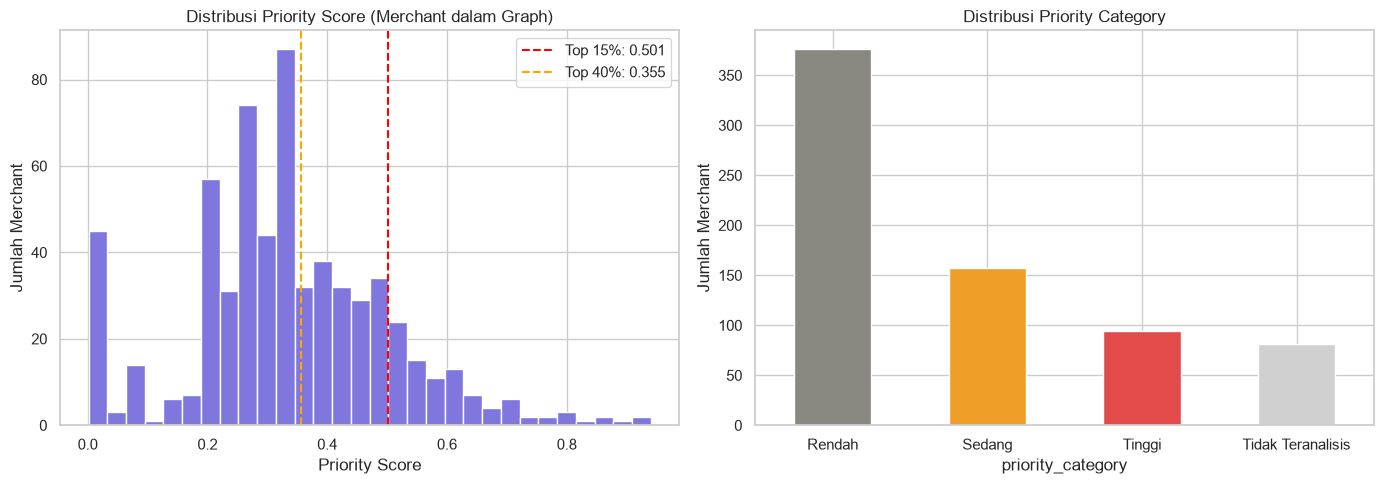

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi skor
axes[0].hist(ft[ft['in_graph']]['priority_score'], bins=30,
             color='#7F77DD', edgecolor='white')
axes[0].axvline(q85, color='red', linestyle='--', label=f'Top 15%: {q85:.3f}')
axes[0].axvline(q60, color='orange', linestyle='--', label=f'Top 40%: {q60:.3f}')
axes[0].set_title('Distribusi Priority Score (Merchant dalam Graph)')
axes[0].set_xlabel('Priority Score')
axes[0].set_ylabel('Jumlah Merchant')
axes[0].legend()

# Breakdown per kategori
cat_counts = ft['priority_category'].value_counts()
colors_map = {'Tinggi': '#E24B4A', 'Sedang': '#EF9F27',
              'Rendah': '#888780', 'Tidak Teranalisis': '#D0D0D0'}
cat_colors = [colors_map.get(c, '#888780') for c in cat_counts.index]
cat_counts.plot(kind='bar', ax=axes[1], color=cat_colors, edgecolor='white')
axes[1].set_title('Distribusi Priority Category')
axes[1].set_ylabel('Jumlah Merchant')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
os.makedirs(f'{PROJECT_ROOT}/plots', exist_ok=True)
plt.savefig(f'{PROJECT_ROOT}/plots/12_priority_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Top 10 prospek akuisisi (non-BNI, skor tertinggi)
top_targets = ft[
    (ft['is_bni_acquiring'] == 'Tidak') &
    (ft['in_graph'])
].nlargest(10, 'priority_score')

print("=== Top 10 Prospek Akuisisi (Non-BNI, by Priority Score) ===")
display_cols = ['merchant_id', 'nama', 'kategori', 'kota',
                'priority_score', 'priority_rank', 'priority_category',
                'degree', 'connected_bni_ratio']
display_cols = [c for c in display_cols if c in top_targets.columns]
print(top_targets[display_cols].to_string())

=== Top 10 Prospek Akuisisi (Non-BNI, by Priority Score) ===
    merchant_id                              nama    kategori       kota  priority_score  priority_rank priority_category  degree  connected_bni_ratio
475       M0675         Langgeng Motor Distribusi  Automotive    Jakarta        0.912438              2            Tinggi    11.0             0.909091
479       M0665   PT Sejahtera Distribusi Mandiri  Automotive  Tangerang        0.862676              4            Tinggi    11.0             0.727273
562       M0232            Sentosa Tekstil Market     Fashion  Tangerang        0.793543              8            Tinggi    10.0             0.700000
544       M0291           Sejahtera Tekstil House     Fashion  Tangerang        0.785341              9            Tinggi    10.0             0.800000
552       M0274   PT Sejahtera Distribusi Sentosa     Fashion      Bogor        0.777506             10            Tinggi    10.0             0.900000
516       M0369  CV Sentosa Distr

In [6]:
# Kolom yang disimpan untuk dipakai dashboard dan notebook 04
SAVE_COLS = [
    'merchant_id', 'nama', 'kategori', 'sub_kategori', 'tipe', 'kota',
    'kecamatan', 'is_bni_acquiring', 'produk_bni', 'avg_omzet_bulanan',
    'degree', 'weighted_degree', 'pagerank', 'betweenness',
    'community_id', 'community_size', 'connected_bni_ratio',
    'avg_neighbor_jaccard', 'n_customers',
    'is_hub', 'customer_density', 'log_omzet',
    'lama_beroperasi_tahun', 'jumlah_karyawan', 'rating_google',
    'jumlah_outlet', 'has_rating', 'has_website', 'has_social_media',
    'in_graph', 'priority_score', 'priority_rank', 'priority_category',
    'predicted_priority', 'priority_probability',
]
SAVE_COLS = [c for c in SAVE_COLS if c in ft.columns]

output = ft[SAVE_COLS].copy()
output.to_csv(f'{PROJECT_ROOT}/data/processed/merchants_with_predictions.csv', index=False)
print(f"Saved: merchants_with_predictions.csv ({len(output)} rows, {len(SAVE_COLS)} kolom)")
print(f"\nKolom yang disimpan: {SAVE_COLS}")

# Simpan scaler untuk dashboard (jika perlu recalculate)
import joblib, os
os.makedirs(f'{PROJECT_ROOT}/models', exist_ok=True)
joblib.dump(scaler, f'{PROJECT_ROOT}/models/priority_scaler.pkl')
joblib.dump(WEIGHTS, f'{PROJECT_ROOT}/models/priority_weights.pkl')
print("Saved: priority_scaler.pkl, priority_weights.pkl")

Saved: merchants_with_predictions.csv (708 rows, 35 kolom)

Kolom yang disimpan: ['merchant_id', 'nama', 'kategori', 'sub_kategori', 'tipe', 'kota', 'kecamatan', 'is_bni_acquiring', 'produk_bni', 'avg_omzet_bulanan', 'degree', 'weighted_degree', 'pagerank', 'betweenness', 'community_id', 'community_size', 'connected_bni_ratio', 'avg_neighbor_jaccard', 'n_customers', 'is_hub', 'customer_density', 'log_omzet', 'lama_beroperasi_tahun', 'jumlah_karyawan', 'rating_google', 'jumlah_outlet', 'has_rating', 'has_website', 'has_social_media', 'in_graph', 'priority_score', 'priority_rank', 'priority_category', 'predicted_priority', 'priority_probability']
Saved: priority_scaler.pkl, priority_weights.pkl


In [7]:
non_bni = ft[ft['is_bni_acquiring'] == 'Tidak']
print("=" * 60)
print("RINGKASAN PRIORITY SCORING")
print("=" * 60)
print(f"Total merchant           : {len(ft)}")
print(f"  Dalam graph (teranalisis): {ft['in_graph'].sum()}")
print(f"  Luar graph (tidak scored): {(~ft['in_graph']).sum()}")
print(f"\nProspek akuisisi (non-BNI): {len(non_bni)}")
print(f"  Prioritas Tinggi : {(non_bni['priority_category']=='Tinggi').sum()}")
print(f"  Prioritas Sedang : {(non_bni['priority_category']=='Sedang').sum()}")
print(f"  Prioritas Rendah : {(non_bni['priority_category']=='Rendah').sum()}")
print(f"  Tidak Teranalisis: {(non_bni['priority_category']=='Tidak Teranalisis').sum()}")
print(f"\nKomponen skor: {WEIGHTS}")
print(f"\nNext: 04_product_recommendation.ipynb")

RINGKASAN PRIORITY SCORING
Total merchant           : 708
  Dalam graph (teranalisis): 627
  Luar graph (tidak scored): 81

Prospek akuisisi (non-BNI): 246
  Prioritas Tinggi : 41
  Prioritas Sedang : 57
  Prioritas Rendah : 126
  Tidak Teranalisis: 22

Komponen skor: {'pagerank': 0.3, 'connected_bni_ratio': 0.25, 'degree': 0.25, 'weighted_degree': 0.2}

Next: 04_product_recommendation.ipynb
